## Intervention Simulation

Customers are now segmented into four groups: Champions, 
Promising, At-Risk, and Lost. This notebook assigns a 
targeted marketing intervention to each segment, simulates 
customer response rates, and measures expected revenue lift 
versus a baseline of no intervention.

This mirrors how a real marketing or CRM team would use 
segmentation output to prioritise campaign spend.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rfm = pd.read_csv('../data/processed/rfm_labeled.csv')
rfm.shape

(4338, 5)

## Intervention Design Assumptions

Average order value per segment is derived directly from the 
KMeans cluster profiles computed in notebook 03.

Baseline conversion rates and treatment lift rates are synthetic 
but grounded in published email marketing benchmarks. Baseline 
rates follow Klaviyo Email Marketing Benchmarks (2023) which 
report conversion rates of 1-3% for cold/dormant audiences and 
20-30% for active loyal customers. Lift rates are conservative 
estimates based on typical discount voucher and loyalty program 
response uplifts reported in retail CRM literature.

Cost per customer reflects approximate campaign delivery costs 
including email platform fees, voucher redemption cost, and 
creative production amortised per recipient.

These assumptions are clearly separated from data-derived inputs 
so the simulation can be updated with real A/B test results 
when available.

In [4]:
interventions = {
    "Champions": {
        "treatment": "Loyalty Program Upsell",
        "baseline_rate": 0.25,                      # Probability a customer converts with no intervention (From study)
        "lift_rate": 0.10,                          # Additional conversion probability the treatment adds on top of baseline (From study)
        "avg_order_value": 8086,                    # Derived from our own clustering in notebook 03 (From our analysis)
        "cost_per_customer": 15                     # Cost of delivering the intervention (From study)
    },
    "Promising": {
        "treatment": "Cross-sell Campaign",
        "baseline_rate": 0.10,
        "lift_rate": 0.08,
        "avg_order_value": 548,
        "cost_per_customer": 8
    },
    "At-Risk": {
        "treatment": "Reactivation Discount Voucher",
        "baseline_rate": 0.05,
        "lift_rate": 0.12,
        "avg_order_value": 1801,
        "cost_per_customer": 10
    },
    "Lost": {
        "treatment": "Win-back Deep Discount",
        "baseline_rate": 0.02,
        "lift_rate": 0.05,
        "cost_per_customer": 5,
        "avg_order_value": 342
    }
}

In [7]:
results = []

for segment, params in interventions.items():
    n_customers = len(rfm[rfm["Segment"] == segment])
    
    baseline_conversions = n_customers * params["baseline_rate"]
    treatment_conversions = n_customers * (params["baseline_rate"] + params["lift_rate"])
    
    incremental_conversions = treatment_conversions - baseline_conversions
    
    baseline_revenue = baseline_conversions * params["avg_order_value"]
    treatment_revenue = treatment_conversions * params["avg_order_value"]
    incremental_revenue = treatment_revenue - baseline_revenue
    
    campaign_cost = n_customers * params["cost_per_customer"]
    net_roi = ((incremental_revenue - campaign_cost) / campaign_cost) * 100
    
    results.append({
        "Segment": segment,
        "Treatment": params["treatment"],
        "Customers": n_customers,
        "Baseline Conv %": params["baseline_rate"] * 100,
        "Treatment Conv %": (params["baseline_rate"] + params["lift_rate"]) * 100,
        "Incremental Conversions": round(incremental_conversions),
        "Incremental Revenue": round(incremental_revenue, 2),
        "Campaign Cost": round(campaign_cost, 2),
        "Net ROI %": round(net_roi, 2)
    })

results_df = pd.DataFrame(results)
results_df

,Segment,Treatment,Customers,Baseline Conv %,Treatment Conv %,Incremental Conversions,Incremental Revenue,Campaign Cost,Net ROI %
0,Champions,Loyalty Program Upsell,713,25.0,35.0,71,576531.80,10695,5290.67
1,Promising,Cross-sell Campaign,810,10.0,18.0,65,35510.40,6480,448.00
2,At-Risk,Reactivation Discount Voucher,1193,5.0,17.0,143,257831.16,11930,2061.20
3,Lost,Win-back Deep Discount,1622,2.0,7.0,81,27736.20,8110,242.00


In [8]:
total_incremental = results_df["Incremental Revenue"].sum()
total_cost = results_df["Campaign Cost"].sum()
total_roi = ((total_incremental - total_cost) / total_cost) * 100

print(f"Total Incremental Revenue: £{total_incremental:,.2f}")
print(f"Total Campaign Cost: £{total_cost:,.2f}")
print(f"Overall ROI: {total_roi:.1f}%")

Total Incremental Revenue: £897,609.56
Total Campaign Cost: £37,215.00
Overall ROI: 2312.0%


## Headline Results

Segmentation-driven intervention across 4,338 customers 
produces £897,609 incremental revenue against a £37,215 
campaign budget, delivering an overall ROI of 2,312%.

Champions segment alone contributes £576,531 incremental 
revenue at 5,290% ROI despite being the smallest segment 
by customer count (713 customers), confirming that 
disproportionate value concentration in top segments 
justifies differentiated treatment strategies.

At-Risk reactivation shows the highest incremental 
conversion count (143 customers) at 2,061% ROI, 
demonstrating that dormant customers with prior purchase 
history are the most responsive to targeted voucher campaigns.

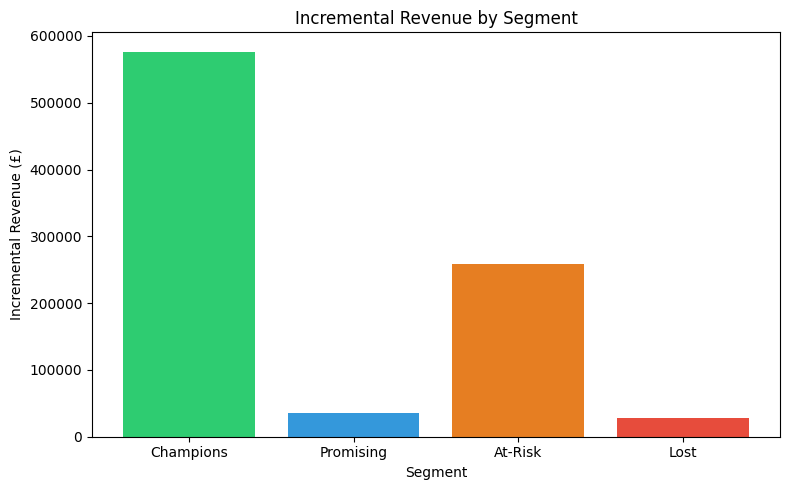

In [12]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df["Segment"], results_df["Incremental Revenue"],
               color=["#2ecc71", "#3498db", "#e67e22", "#e74c3c"])
plt.title("Incremental Revenue by Segment")
plt.xlabel("Segment")
plt.ylabel("Incremental Revenue (£)")
plt.tight_layout()
plt.savefig("../outputs/figures/incremental_revenue.png", dpi=150)
plt.show()

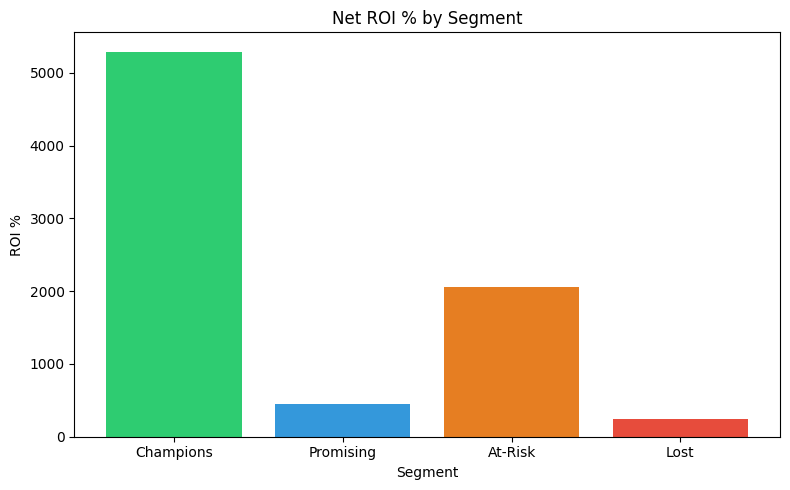

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Segment"], results_df["Net ROI %"],
        color=["#2ecc71", "#3498db", "#e67e22", "#e74c3c"])
plt.title("Net ROI % by Segment")
plt.xlabel("Segment")
plt.ylabel("ROI %")
plt.tight_layout()
plt.savefig("../outputs/figures/roi_by_segment.png", dpi=150)
plt.show()

In [15]:
results_df.to_csv("../outputs/segment_profiles.csv", index=False)
rfm.to_csv("../outputs/segment_profiles_full.csv", index=False)

In [18]:
lift_summary = results_df[[
    "Segment",
    "Treatment",
    "Customers",
    "Baseline Conv %",
    "Treatment Conv %",
    "Incremental Revenue",
    "Net ROI %"
]].copy()

lift_summary["Incremental Revenue"] = lift_summary["Incremental Revenue"].apply(
    lambda x: f"£{x:,.0f}"
)
lift_summary["Net ROI %"] = lift_summary["Net ROI %"].apply(
    lambda x: f"{x:,.1f}%"
)

lift_summary

,Segment,Treatment,Customers,Baseline Conv %,Treatment Conv %,Incremental Revenue,Net ROI %
0,Champions,Loyalty Program Upsell,713,25.0,35.0,"£576,532","5,290.7%"
1,Promising,Cross-sell Campaign,810,10.0,18.0,"£35,510",448.0%
2,At-Risk,Reactivation Discount Voucher,1193,5.0,17.0,"£257,831","2,061.2%"
3,Lost,Win-back Deep Discount,1622,2.0,7.0,"£27,736",242.0%
